In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.3.3 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/opt/anaconda3/lib/python3.12/site-packages/ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "/opt/anaconda3/lib/python3.12/site-packages/traitlets/config/application.py", line 1075, in launch_instance
    app.start()
  File "/opt/anaconda3/lib/python3.12/site-packages/ipykernel/kernelapp.py", line 701, in start
    self.io_loop.start()
  File "/opt/anaconda3/lib/python3.12/site-

AttributeError: _ARRAY_API not found


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.3.3 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/opt/anaconda3/lib/python3.12/site-packages/ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "/opt/anaconda3/lib/python3.12/site-packages/traitlets/config/application.py", line 1075, in launch_instance
    app.start()
  File "/opt/anaconda3/lib/python3.12/site-packages/ipykernel/kernelapp.py", line 701, in start
    self.io_loop.start()
  File "/opt/anaconda3/lib/python3.12/site-

ImportError: 
A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.3.3 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.



In [3]:
stats = pd.read_csv("all_stats_vs_revenue_2.csv")
coins = pd.read_csv("coin_revenues.csv")

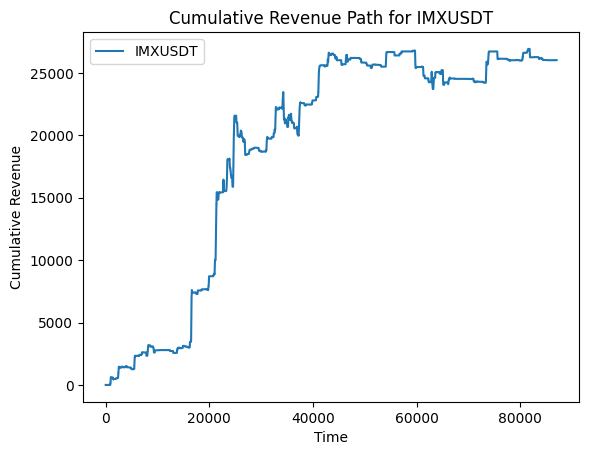

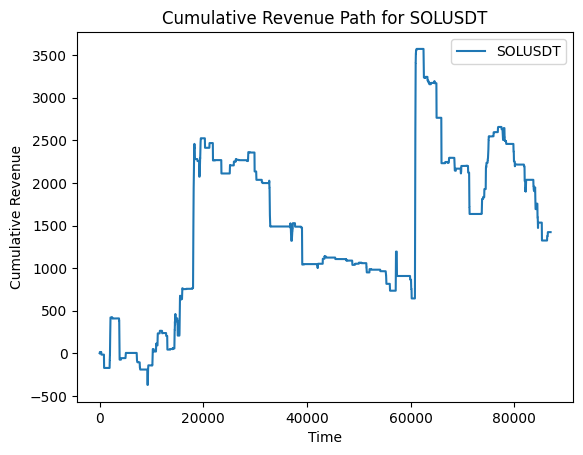

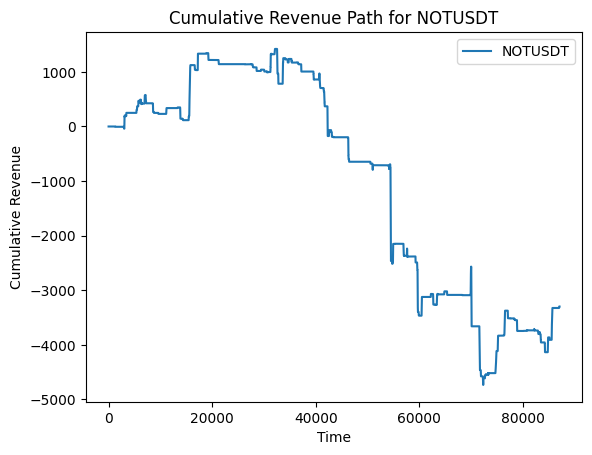

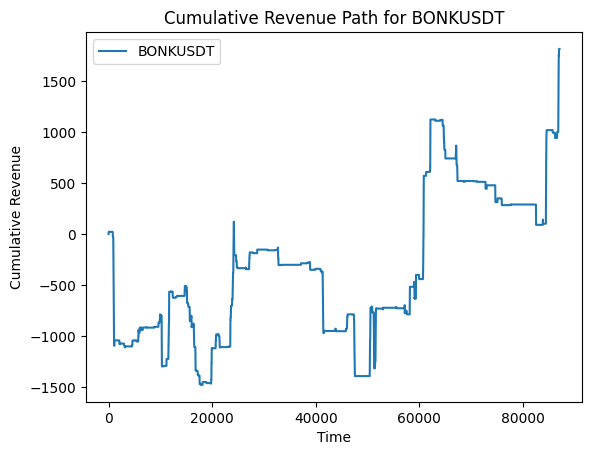

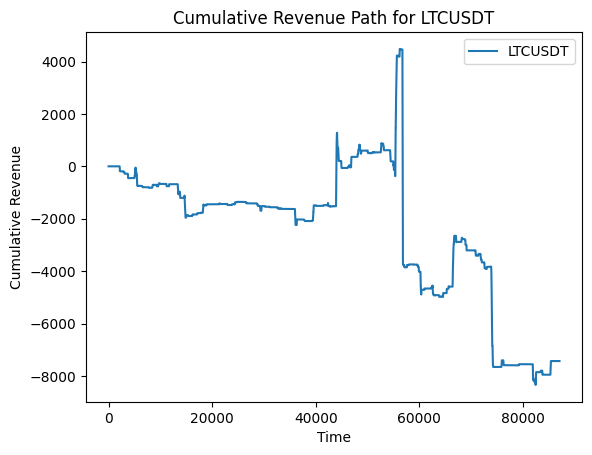

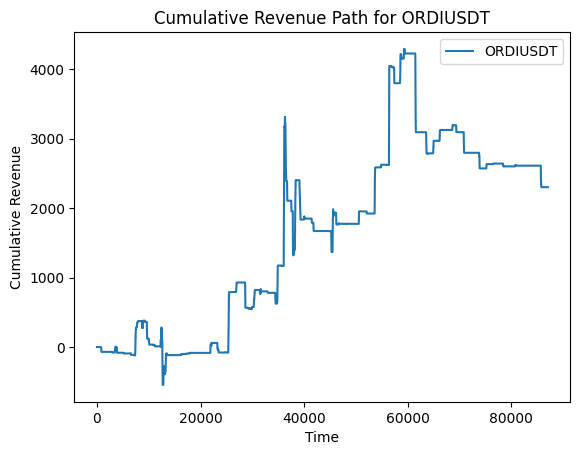

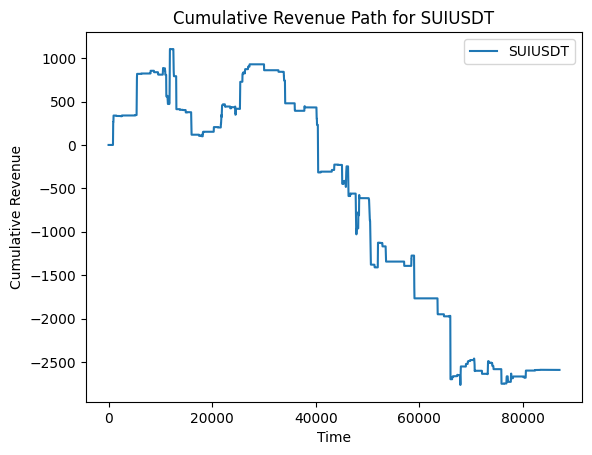

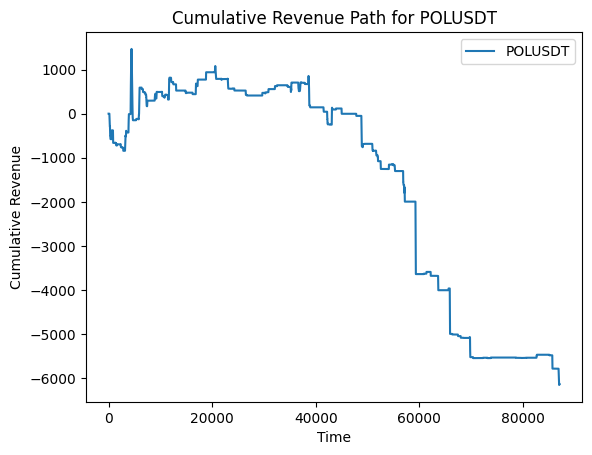

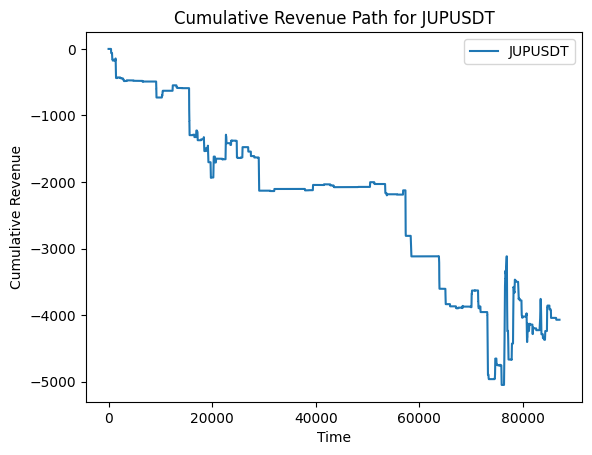

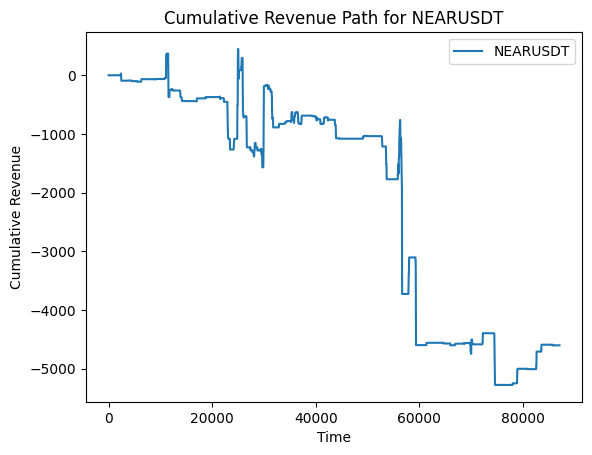

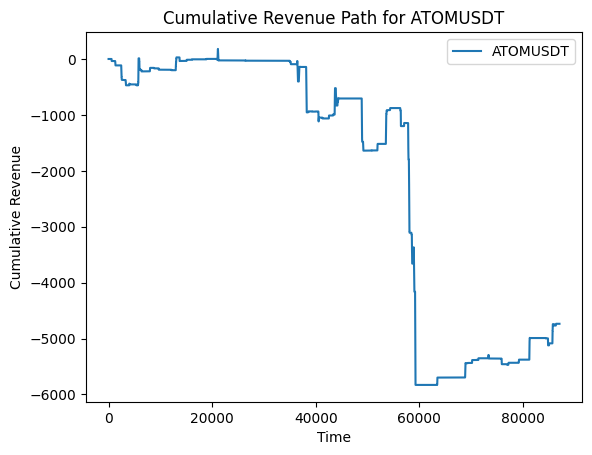

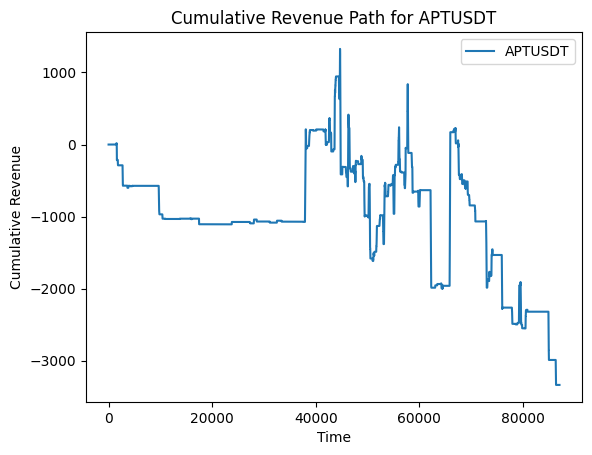

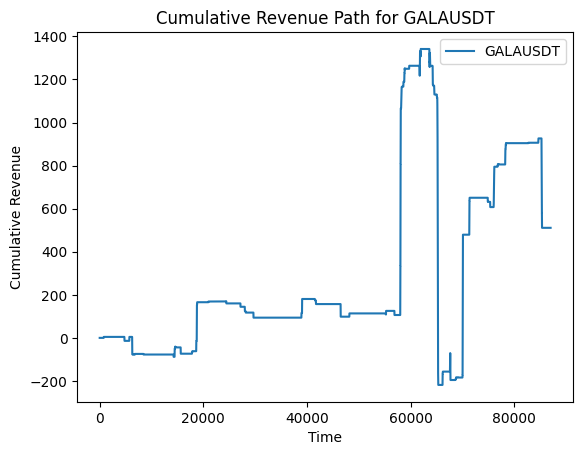

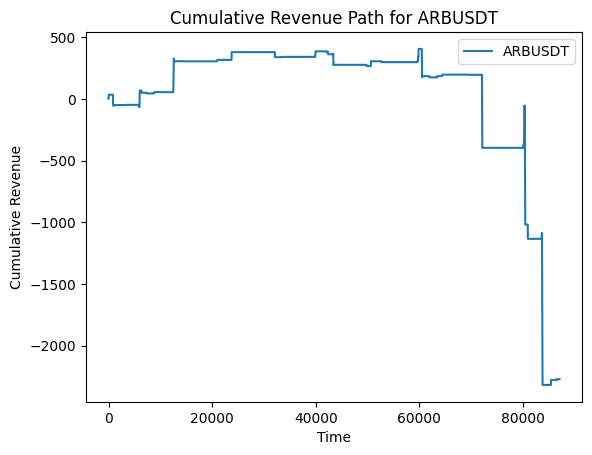

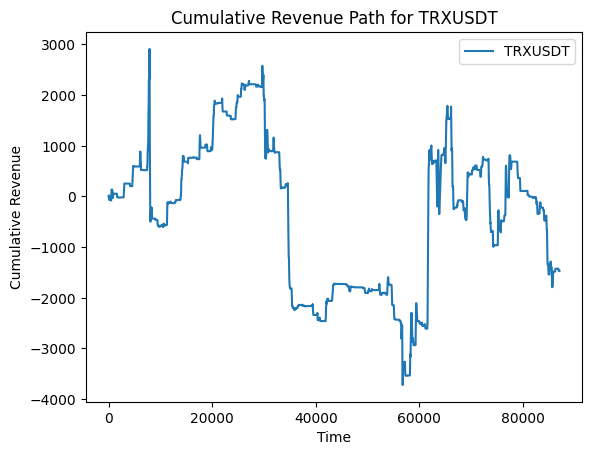

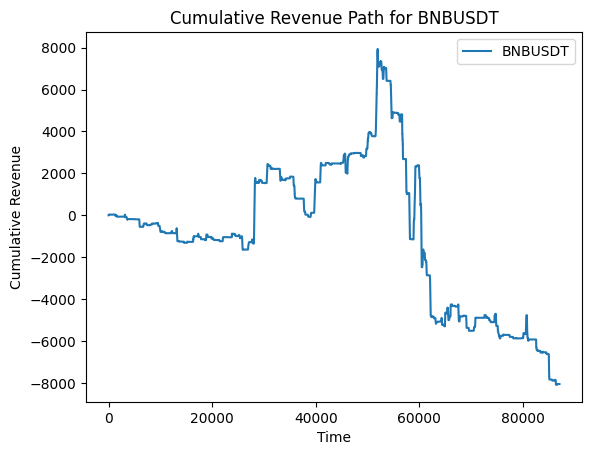

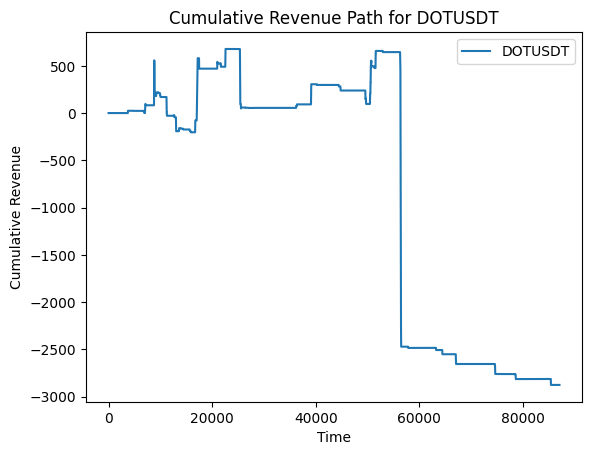

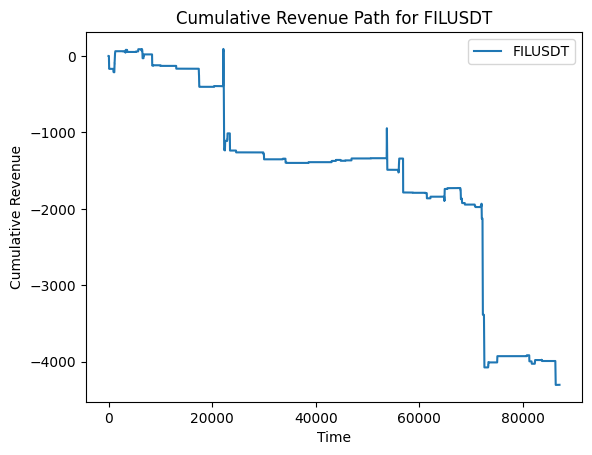

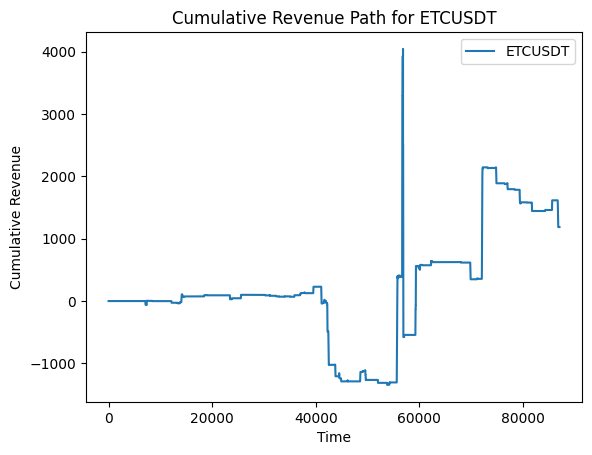

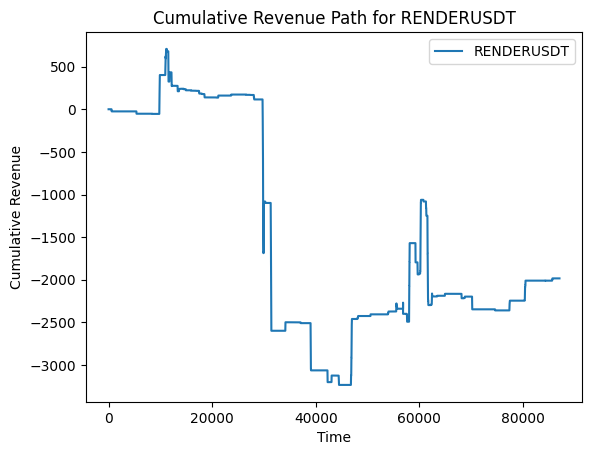

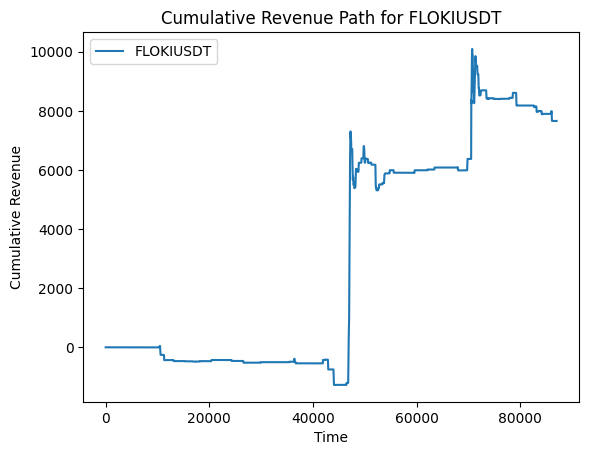

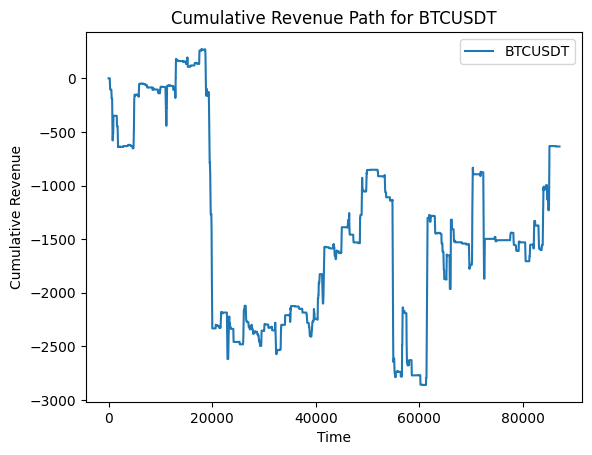

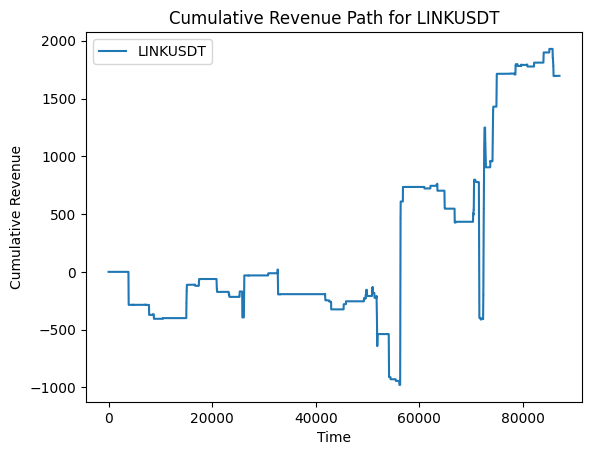

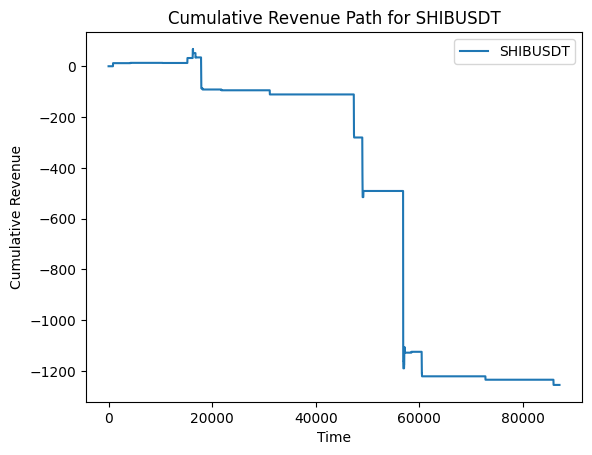

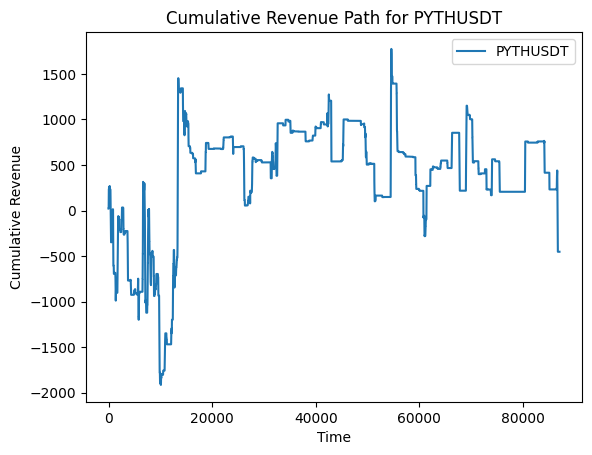

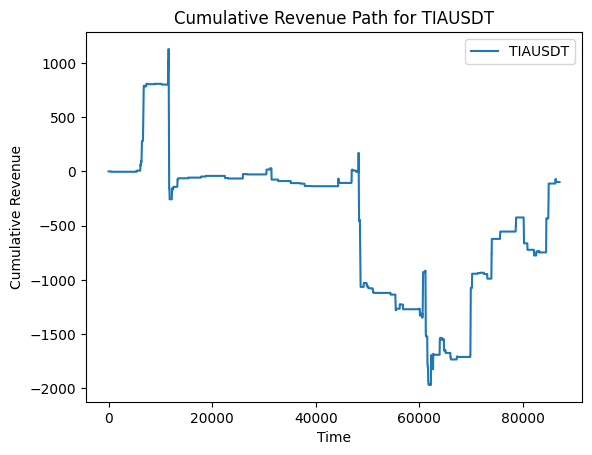

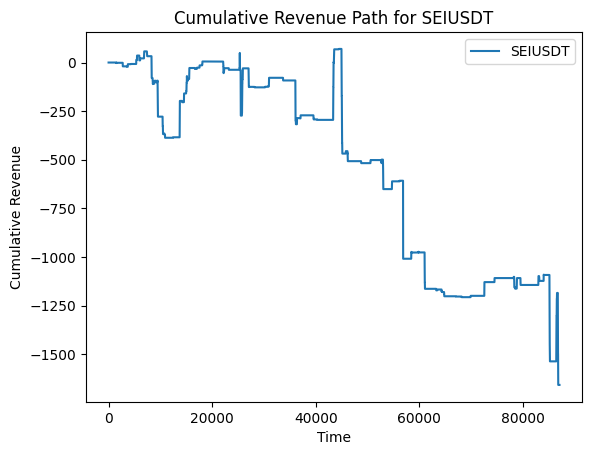

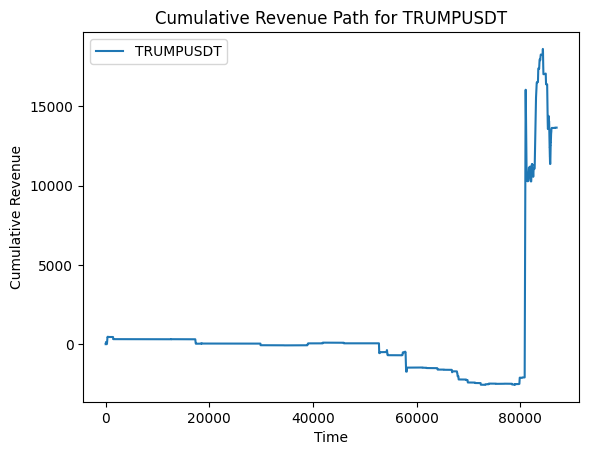

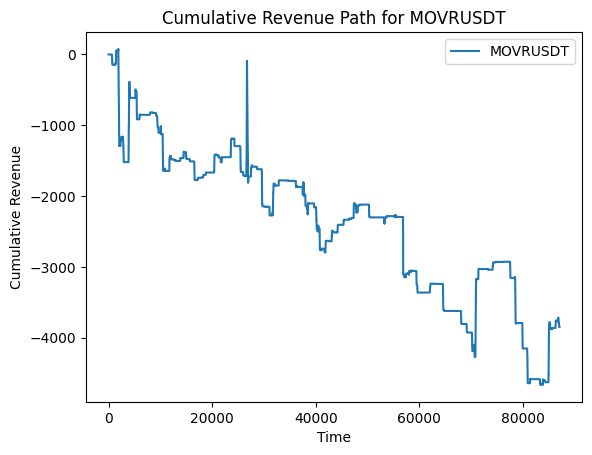

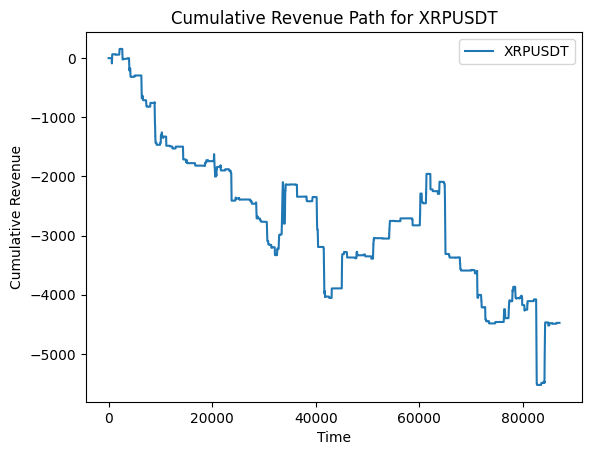

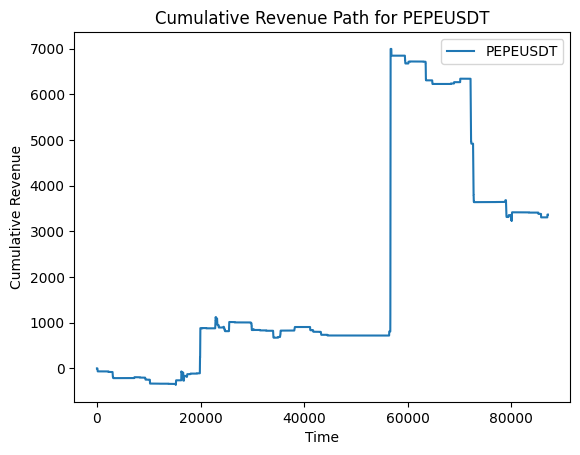

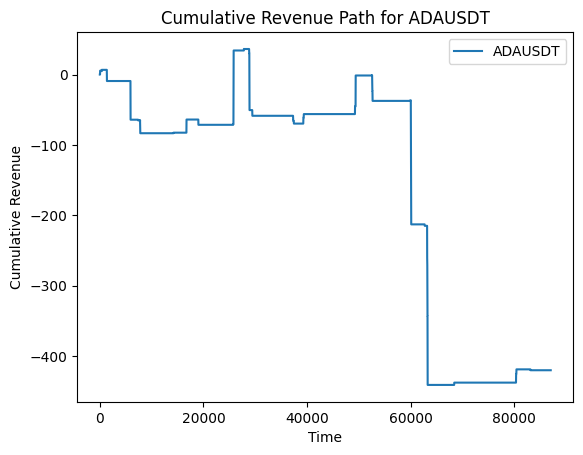

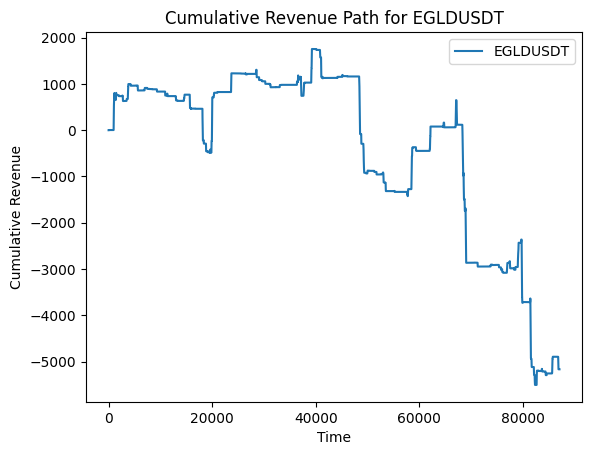

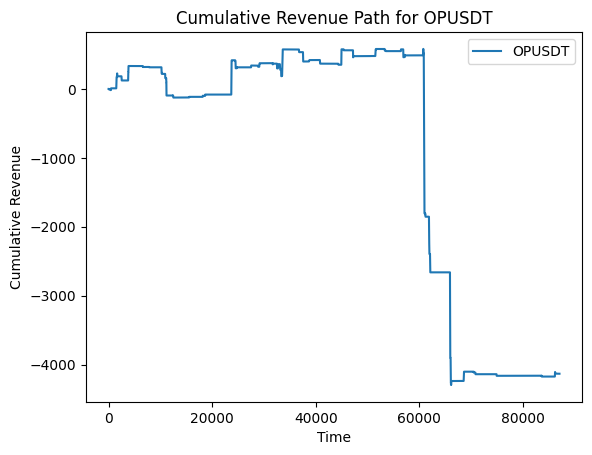

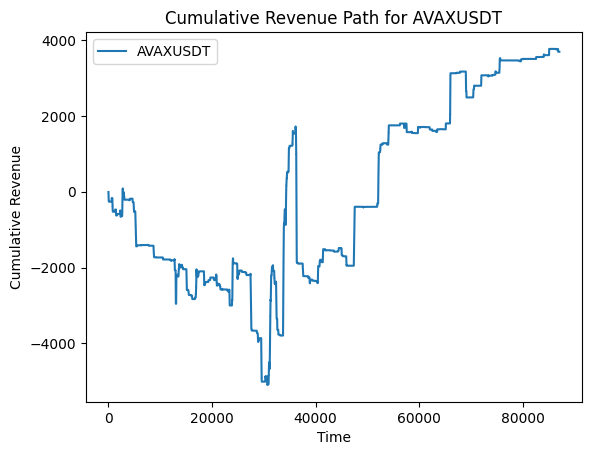

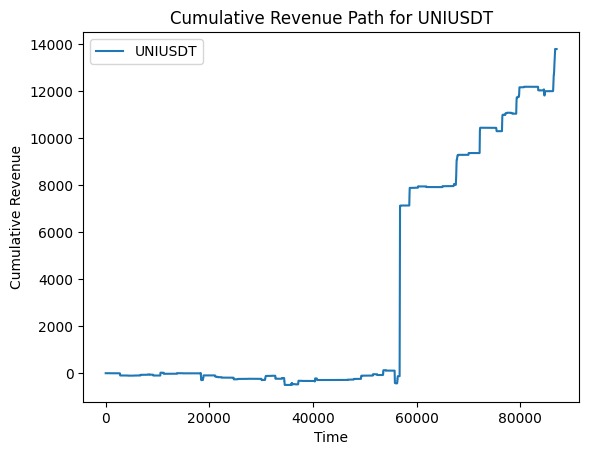

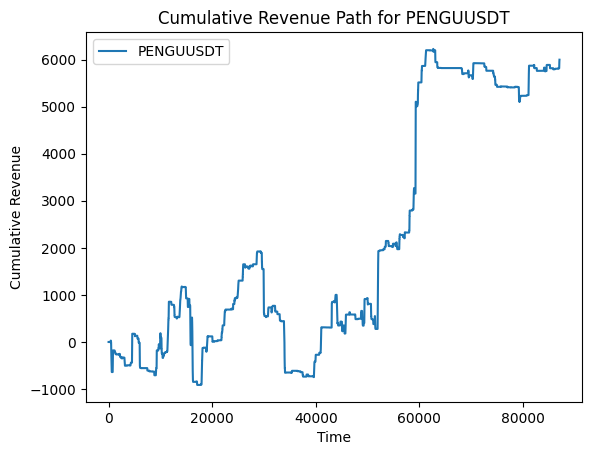

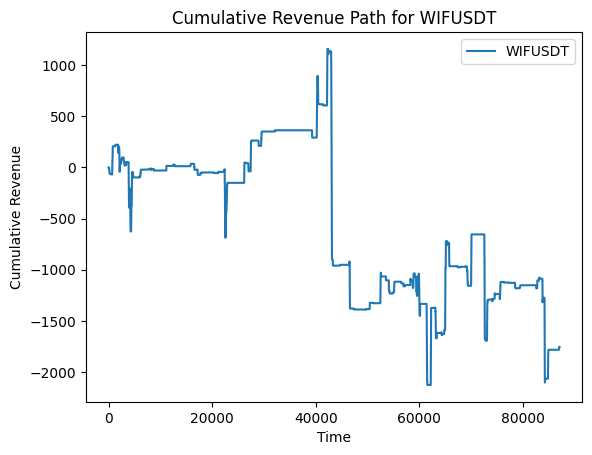

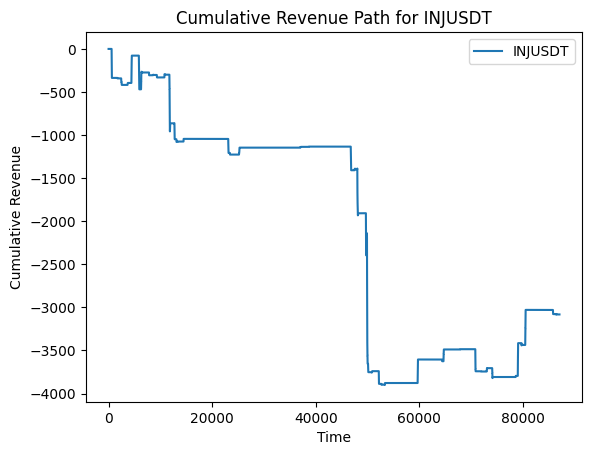

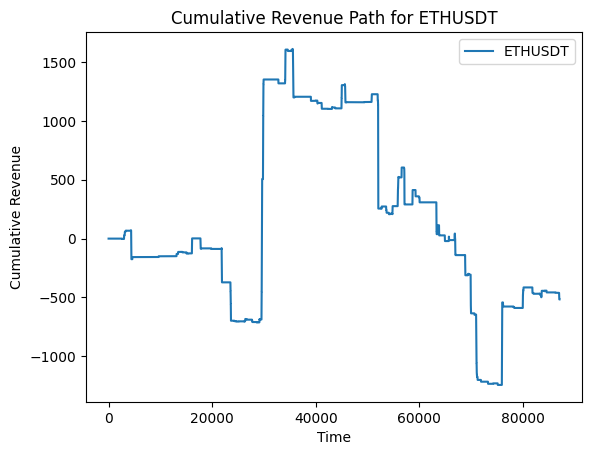

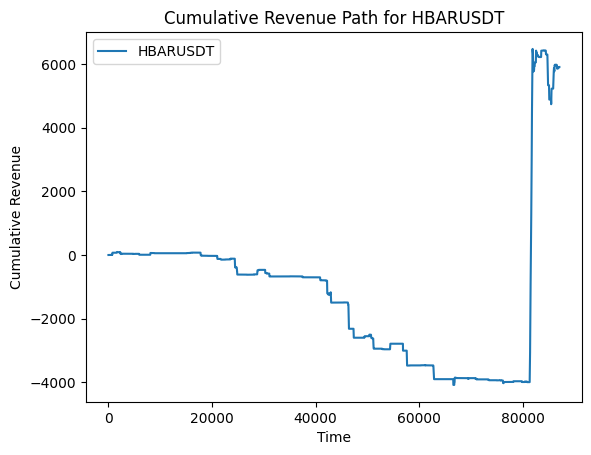

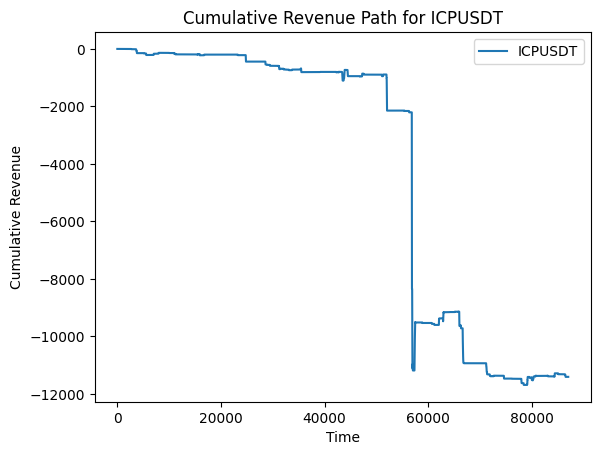

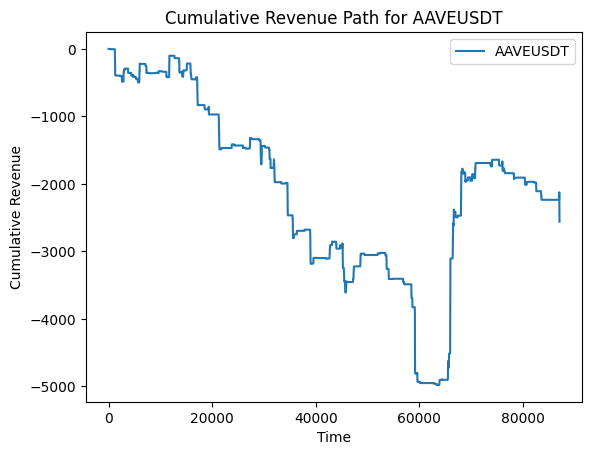

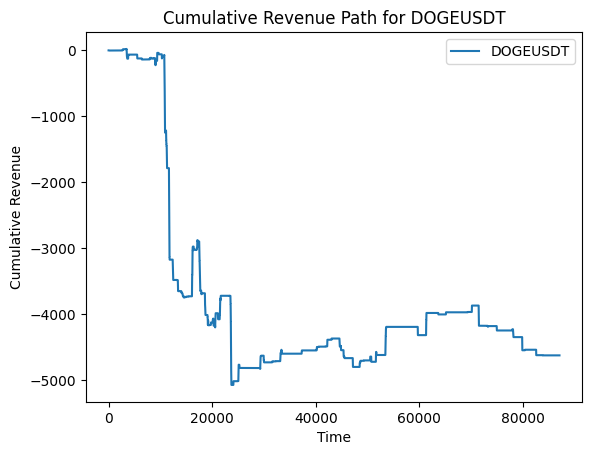

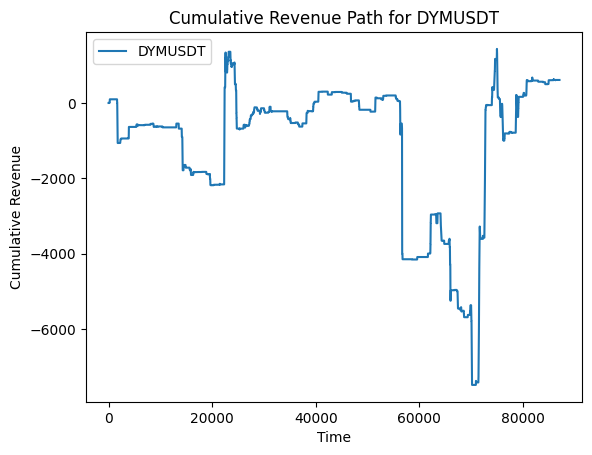

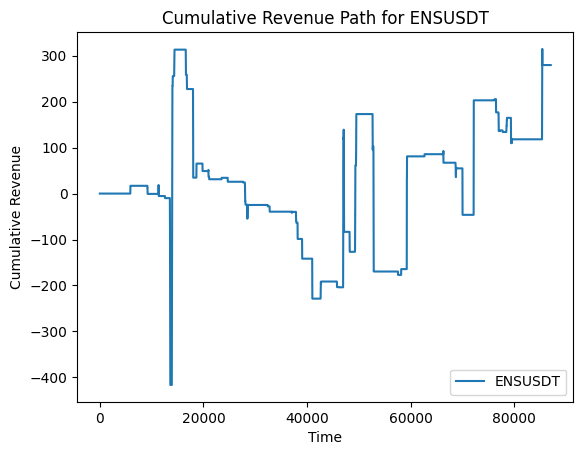

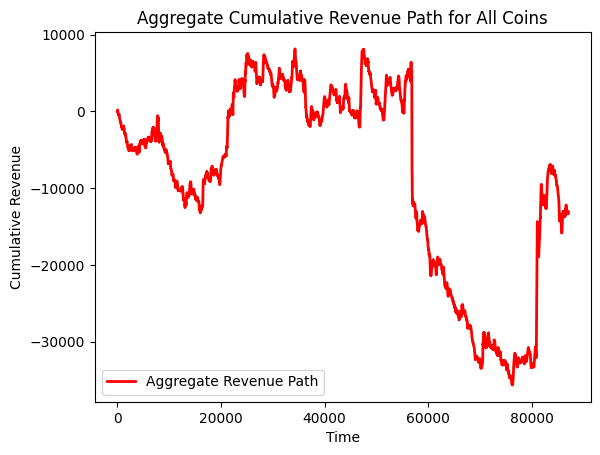

In [4]:
all_path = None

for coin in coins.columns:
    if coin == 'Unnamed: 0':
        continue
    coin_revs = np.array(coins[coin].dropna())
    coin_path = coin_revs.cumsum()
    if all_path is None:
        all_path = coin_path
    else:
        all_path = all_path + coin_path

    plt.plot(coin_path, label=coin)
    plt.title(f"Cumulative Revenue Path for {coin}")
    plt.xlabel("Time")
    plt.ylabel("Cumulative Revenue")
    plt.legend()
    plt.show()
    plt.close()
  
plt.plot(all_path, label="Aggregate Revenue Path", color='red', linewidth=2)
plt.title("Aggregate Cumulative Revenue Path for All Coins")
plt.xlabel("Time")
plt.ylabel("Cumulative Revenue")
plt.legend()
plt.show()
plt.close()

In [5]:
stats.columns

Index(['stats_1', 'stats_2', 'stats_3', 'stats_4', 'stats_5', 'stats_6',
       'stats_7', 'stats_8', 'stats_9', 'stats_10', 'revenues'],
      dtype='object')

=== Filtering Analysis ===
Total entries: 87040
Qualifying entries: 13701
Filtering rate: 15.74%
Original total revenue: -1788.433380
Filtered total revenue: 13978.181930
Revenue retention: -781.59%


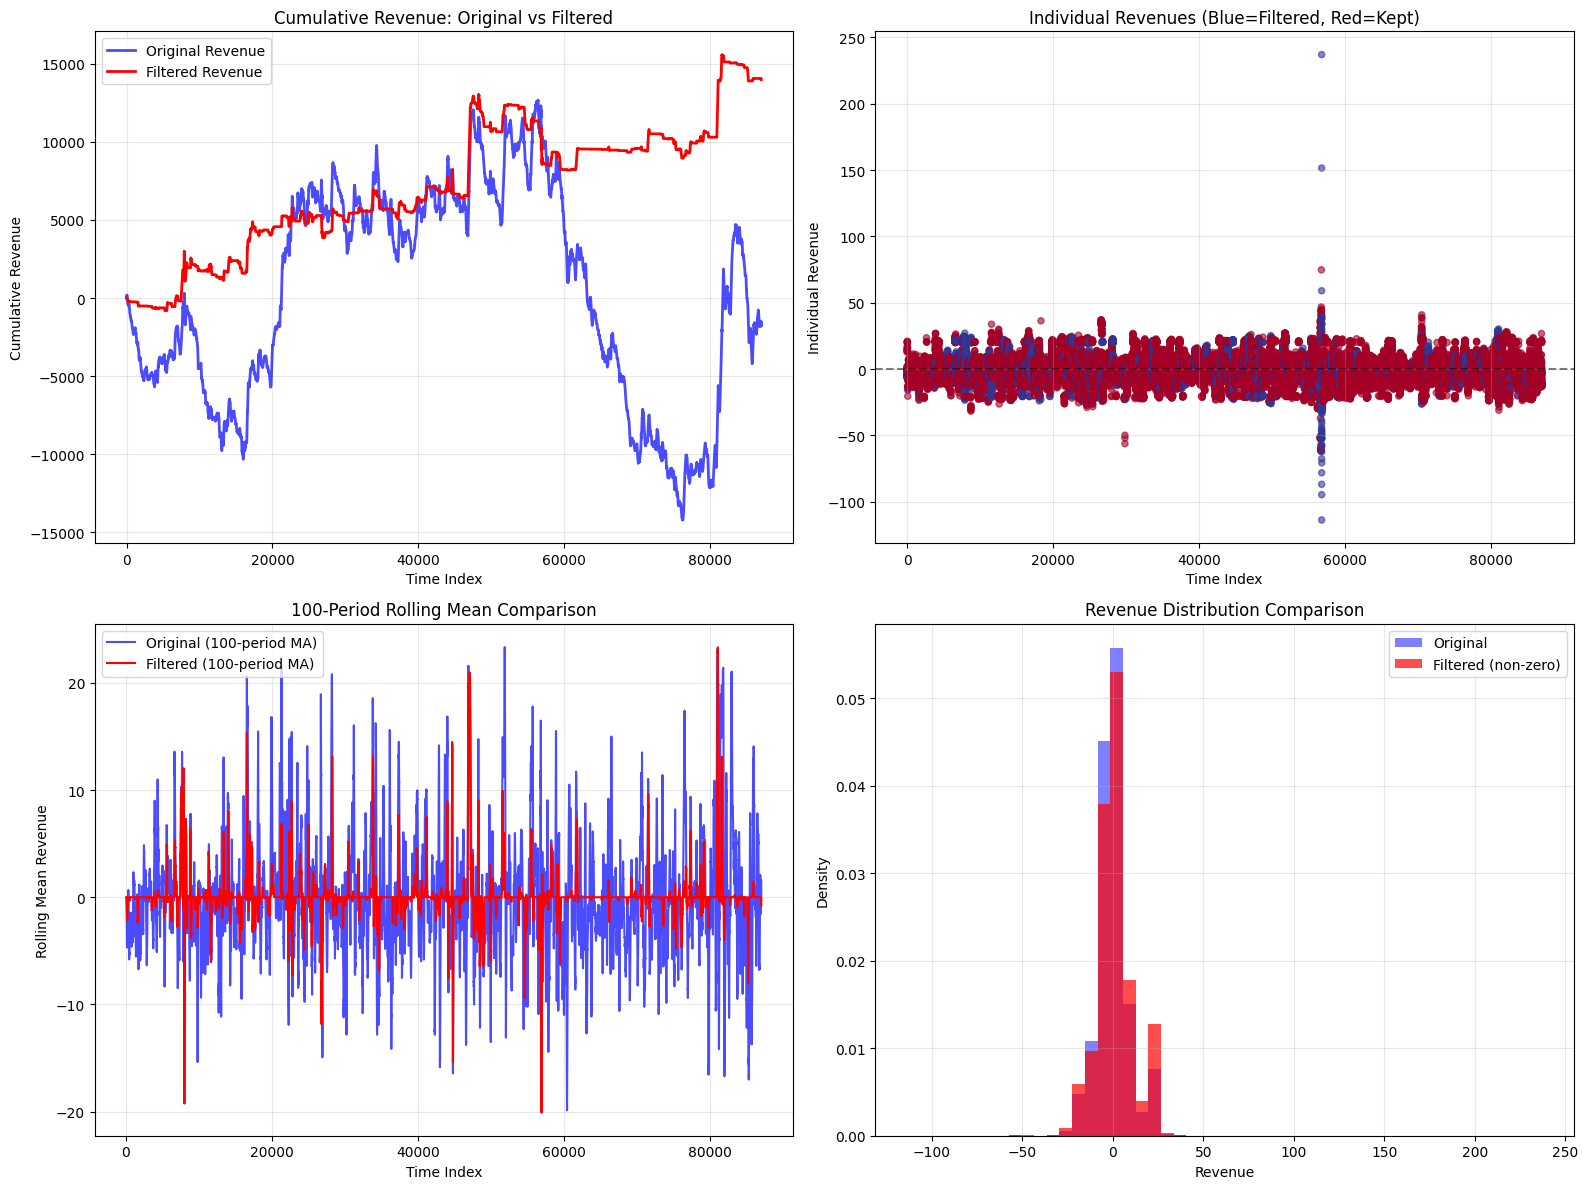


=== Performance Metrics ===
Original Revenue Stats:
  Mean: -0.020547
  Std:  8.623122
  Sharpe: -0.0024
  Win Rate: 46.47%

Filtered Revenue Stats (non-zero only):
  Mean: 1.020231
  Std:  10.359126
  Sharpe: 0.0985
  Win Rate: 51.84%

Filtered Revenue Stats (including zeros):
  Mean: 0.160595
  Std:  4.126616
  Sharpe: 0.0389
  Win Rate: 8.16%

=== Time-based Analysis ===
Chunk size: 100
Number of chunks: 871
Original chunk mean: -2.053310
Filtered chunk mean: 16.048429


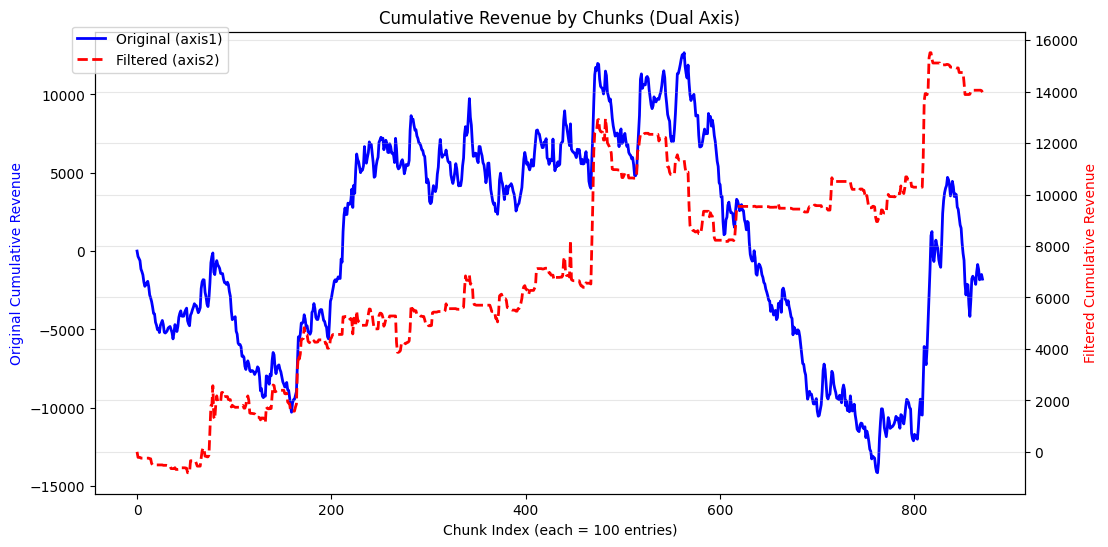


=== Filter Condition Analysis ===
Individual condition pass rates:
  stats_6 > 0.1:     20.64%
  stats_5 > 0.6:     46.90%
  stats_9 < 6:       94.94%
  stats_1 < -7500:   91.25%
  |stats_8| < 10:    81.93%
  All conditions:    15.74%


In [18]:
# if res.success and corr_2_mean>0.1 and corr_1_mean>0.6 and cmi_std<6 and objective_value < -7500  and abs(cmi_mean)<10:

# stats_1.append(objective_value)
# stats_2.append(coef_1_mean)
# stats_3.append(coef_2_mean)
# stats_4.append(coef_3_mean)
# stats_5.append(corr_1_mean)
# stats_6.append(corr_2_mean)
# stats_7.append(corr_3_mean)
# stats_8.append(cmi_mean)
# stats_9.append(cmi_std)
# stats_10.append(amihud_mean)

# Create filtered revenue series with 0s for non-qualifying entries
filtered_revenues = stats['revenues'].copy()

# Set revenues to 0 where conditions are not met
condition_mask = (
    # (stats['stats_6'] > 0.1) &
    # (stats['stats_5'] > 0.6) &
    # (stats['stats_9'] < 6) &
    (stats['stats_1'] < -15000) 
    # (stats['stats_8'].abs() < 15) & 
    #  (stats['stats_8'].abs() > 7.5) 
)

# Where condition is False, set revenue to 0
filtered_revenues[~condition_mask] = 0

# Calculate cumulative sum
cumulative_filtered = filtered_revenues.cumsum()
cumulative_original = stats['revenues'].cumsum()

# Print statistics
print("=== Filtering Analysis ===")
print(f"Total entries: {len(stats)}")
print(f"Qualifying entries: {condition_mask.sum()}")
print(f"Filtering rate: {condition_mask.sum() / len(stats):.2%}")
print(f"Original total revenue: {stats['revenues'].sum():.6f}")
print(f"Filtered total revenue: {filtered_revenues.sum():.6f}")
print(f"Revenue retention: {filtered_revenues.sum() / stats['revenues'].sum():.2%}")

# Create comprehensive plots
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Cumulative revenue comparison
axes[0, 0].plot(cumulative_original.index, cumulative_original.values, 
                label='Original Revenue', color='blue', alpha=0.7, linewidth=2)
axes[0, 0].plot(cumulative_filtered.index, cumulative_filtered.values, 
                label='Filtered Revenue', color='red', linewidth=2)
axes[0, 0].set_xlabel('Time Index')
axes[0, 0].set_ylabel('Cumulative Revenue')
axes[0, 0].set_title('Cumulative Revenue: Original vs Filtered')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Individual revenues with filtering
axes[0, 1].scatter(range(len(stats)), stats['revenues'], 
                   c=condition_mask, cmap='RdYlBu', alpha=0.6, s=20)
axes[0, 1].axhline(y=0, color='black', linestyle='--', alpha=0.5)
axes[0, 1].set_xlabel('Time Index')
axes[0, 1].set_ylabel('Individual Revenue')
axes[0, 1].set_title('Individual Revenues (Blue=Filtered, Red=Kept)')
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Rolling statistics
window = 100
rolling_original = stats['revenues'].rolling(window).mean()
rolling_filtered = filtered_revenues.rolling(window).mean()

axes[1, 0].plot(rolling_original.index, rolling_original.values, 
                label=f'Original ({window}-period MA)', color='blue', alpha=0.7)
axes[1, 0].plot(rolling_filtered.index, rolling_filtered.values, 
                label=f'Filtered ({window}-period MA)', color='red')
axes[1, 0].set_xlabel('Time Index')
axes[1, 0].set_ylabel('Rolling Mean Revenue')
axes[1, 0].set_title(f'{window}-Period Rolling Mean Comparison')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Plot 4: Histogram comparison
axes[1, 1].hist(stats['revenues'], bins=50, alpha=0.5, label='Original', 
                color='blue', density=True)
axes[1, 1].hist(filtered_revenues[filtered_revenues != 0], bins=50, alpha=0.7, 
                label='Filtered (non-zero)', color='red', density=True)
axes[1, 1].set_xlabel('Revenue')
axes[1, 1].set_ylabel('Density')
axes[1, 1].set_title('Revenue Distribution Comparison')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Detailed performance analysis
print("\n=== Performance Metrics ===")
print(f"Original Revenue Stats:")
print(f"  Mean: {stats['revenues'].mean():.6f}")
print(f"  Std:  {stats['revenues'].std():.6f}")
print(f"  Sharpe: {stats['revenues'].mean() / stats['revenues'].std():.4f}")
print(f"  Win Rate: {(stats['revenues'] > 0).mean():.2%}")

print(f"\nFiltered Revenue Stats (non-zero only):")
non_zero_filtered = filtered_revenues[filtered_revenues != 0]
if len(non_zero_filtered) > 0:
    print(f"  Mean: {non_zero_filtered.mean():.6f}")
    print(f"  Std:  {non_zero_filtered.std():.6f}")
    print(f"  Sharpe: {non_zero_filtered.mean() / non_zero_filtered.std():.4f}")
    print(f"  Win Rate: {(non_zero_filtered > 0).mean():.2%}")
else:
    print("  No qualifying entries!")

print(f"\nFiltered Revenue Stats (including zeros):")
print(f"  Mean: {filtered_revenues.mean():.6f}")
print(f"  Std:  {filtered_revenues.std():.6f}")
print(f"  Sharpe: {filtered_revenues.mean() / filtered_revenues.std():.4f}")
print(f"  Win Rate: {(filtered_revenues > 0).mean():.2%}")

# Monthly/yearly analysis if applicable
print(f"\n=== Time-based Analysis ===")
chunk_size = 100  # Adjust based on your data frequency

chunks_original = [stats['revenues'].iloc[i:i+chunk_size].sum() 
                  for i in range(0, len(stats), chunk_size)]
chunks_filtered = [filtered_revenues.iloc[i:i+chunk_size].sum() 
                  for i in range(0, len(filtered_revenues), chunk_size)]

print(f"Chunk size: {chunk_size}")
print(f"Number of chunks: {len(chunks_original)}")
print(f"Original chunk mean: {np.mean(chunks_original):.6f}")
print(f"Filtered chunk mean: {np.mean(chunks_filtered):.6f}")

fig, ax1 = plt.subplots(figsize=(12, 6))
ax2 = ax1.twinx()
chunk_indices = range(len(chunks_original))
ax1.plot(chunk_indices, np.cumsum(chunks_original), 'b-', label='Original (axis1)', linewidth=2)
ax2.plot(chunk_indices, np.cumsum(chunks_filtered), 'r--', label='Filtered (axis2)', linewidth=2)
ax1.set_xlabel(f'Chunk Index (each = {chunk_size} entries)')
ax1.set_ylabel('Original Cumulative Revenue', color='b')
ax2.set_ylabel('Filtered Cumulative Revenue', color='r')
plt.title('Cumulative Revenue by Chunks (Dual Axis)')
fig.legend(loc='upper left', bbox_to_anchor=(0.1, 0.9))
plt.grid(True, alpha=0.3)
plt.show()

# Filter condition analysis
print(f"\n=== Filter Condition Analysis ===")
print("Individual condition pass rates:")
print(f"  stats_6 > 0.1:     {(stats['stats_6'] > 0.1).mean():.2%}")
print(f"  stats_5 > 0.6:     {(stats['stats_5'] > 0.6).mean():.2%}")
print(f"  stats_9 < 6:       {(stats['stats_9'] < 6).mean():.2%}")
print(f"  stats_1 < -7500:   {(stats['stats_1'] < -7500).mean():.2%}")
print(f"  |stats_8| < 10:    {(stats['stats_8'].abs() < 10).mean():.2%}")
print(f"  All conditions:    {condition_mask.mean():.2%}")

# Save results
results_df = pd.DataFrame({
    'original_revenue': stats['revenues'],
    'filtered_revenue': filtered_revenues,
    'cumulative_original': cumulative_original,
    'cumulative_filtered': cumulative_filtered,
    'condition_met': condition_mask
})


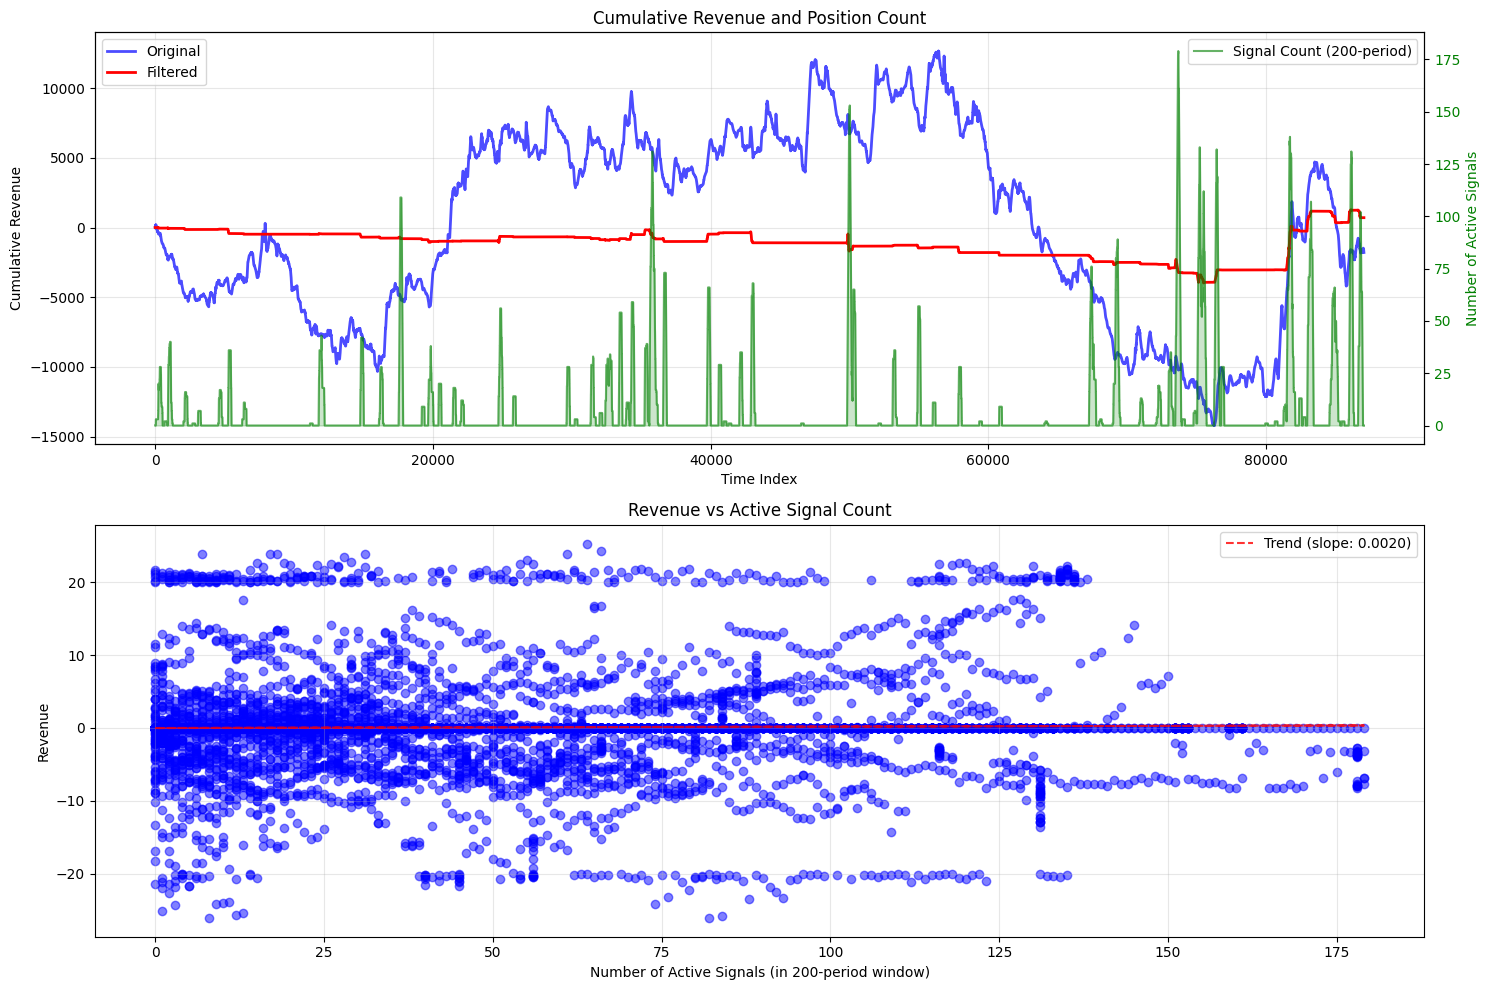


=== Signal Count Analysis (200-period window) ===
Average signals active: 7.70
Max signals active: 179
Min signals active: 0
Median signals active: 0.00
                  signal_count_min  signal_count_max  signal_count_mean  \
bin                                                                       
(-0.001, 1.0]                  0.0               1.0             0.4812   
(1.0, 2.0]                     2.0               2.0             2.0000   
(2.0, 3.0]                     3.0               3.0             3.0000   
(3.0, 4.0]                     4.0               4.0             4.0000   
(4.0, 6.0]                     5.0               6.0             5.4954   
(6.0, 9.0]                     7.0               9.0             7.9870   
(9.0, 11.0]                   10.0              11.0            10.4896   
(11.0, 13.0]                  12.0              13.0            12.4835   
(13.0, 16.0]                  14.0              16.0            14.9922   
(16.0, 19.0]         

/var/folders/j9/n79dq8zs23qbyhwf5323s_lw0000gn/T/ipykernel_70680/4077440391.py:69: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  stats_by_bin = revenue_nonzero.groupby('bin').agg({


In [7]:
# Modified signal count analysis
window = 200
signal_counts = pd.Series(np.zeros(len(stats)), index=stats.index)
for i in range(len(stats)):
    if i >= window:
        signal_counts[i] = condition_mask[i-window:i].sum()
    else:
        signal_counts[i] = condition_mask[:i].sum()

# Create plot with dual y-axes
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10))

# Plot 1: Cumulative Revenue with Signal Count
ax1.plot(cumulative_original.index, cumulative_original.values, 
         label='Original', color='blue', alpha=0.7, linewidth=2)
ax1.plot(cumulative_filtered.index, cumulative_filtered.values, 
         label='Filtered', color='red', linewidth=2)
ax1.set_xlabel('Time Index')
ax1.set_ylabel('Cumulative Revenue')
ax1.set_title('Cumulative Revenue and Position Count')
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.3)

# Add position count on secondary y-axis
ax12 = ax1.twinx()
ax12.fill_between(signal_counts.index, signal_counts.values, alpha=0.2, color='green')
ax12.plot(signal_counts.index, signal_counts.values, color='green', alpha=0.6, 
          label=f'Signal Count ({window}-period)')
ax12.set_ylabel('Number of Active Signals', color='green')
ax12.tick_params(axis='y', labelcolor='green')
ax12.legend(loc='upper right')

# Plot 2: Signal Count vs Revenue with Enhanced Analysis
ax2.scatter(signal_counts, filtered_revenues, alpha=0.5, c='blue')
ax2.set_xlabel(f'Number of Active Signals (in {window}-period window)')
ax2.set_ylabel('Revenue')
ax2.set_title('Revenue vs Active Signal Count')
ax2.grid(True, alpha=0.3)

# Add trend line
z = np.polyfit(signal_counts, filtered_revenues, 1)
p = np.poly1d(z)
ax2.plot(signal_counts, p(signal_counts), "r--", alpha=0.8, 
         label=f'Trend (slope: {z[0]:.4f})')
ax2.legend()

plt.tight_layout()
plt.show()

# Print basic statistics
print(f"\n=== Signal Count Analysis ({window}-period window) ===")
print(f"Average signals active: {signal_counts.mean():.2f}")
print(f"Max signals active: {signal_counts.max():.0f}")
print(f"Min signals active: {signal_counts.min():.0f}")
print(f"Median signals active: {signal_counts.median():.2f}")

# Modified quantile analysis to handle duplicates
# Create custom bins based on signal distribution
signal_bins = pd.qcut(signal_counts, q=80, duplicates='drop')
revenue_by_signals = pd.DataFrame({
    'signal_count': signal_counts,
    'revenue': filtered_revenues,
    'bin': signal_bins
})
# 只保留 revenue ≠ 0 的记录
revenue_nonzero = revenue_by_signals[revenue_by_signals['revenue'] != 0]

# 按 bin 分组统计
stats_by_bin = revenue_nonzero.groupby('bin').agg({
    'signal_count': ['min', 'max', 'mean', 'count'],
    'revenue': [
        'mean', 
        'std', 
        ('pos_ratio', lambda x: (x > 0).mean())  # 自定义命名: 正收益比例
    ]
}).round(4)

# 整理列名
stats_by_bin.columns = ['_'.join(col).strip() for col in stats_by_bin.columns.values]

print(stats_by_bin)

# Additional analysis of extreme cases
high_signal_periods = revenue_by_signals[revenue_by_signals['signal_count'] > signal_counts.quantile(0.9)]
print("\nHigh Signal Periods Analysis (top 10%):")
print(f"Number of periods: {len(high_signal_periods)}")
print(f"Average revenue: {high_signal_periods['revenue'].mean():.4f}")
print(f"Win rate: {(high_signal_periods['revenue'] > 0).mean():.2%}")

In [8]:
# random_seed = 42
# np.random.seed(random_seed)
# train_frac = 0.6
# size = len(stats)
# train_size = int(size * train_frac)
# shuffled_indices = np.random.permutation(size)
# train_indices = shuffled_indices[:train_size]
# test_indices = shuffled_indices[train_size:]
# train_set = stats.iloc[train_indices]
# test_set = stats.iloc[test_indices]

train_set = stats[:int(0.6*len(stats))]
test_set = stats[int(0.6*len(stats)):]

In [9]:
train_means = train_set.mean()
test_means = test_set.mean()


In [10]:
train_means

stats_1     -12202.057376
stats_2         23.197722
stats_3          0.812495
stats_4     920872.869649
stats_5          0.541964
stats_6          0.042826
stats_7          0.654013
stats_8          0.135149
stats_9          4.463314
stats_10     52646.307008
revenues         0.202730
dtype: float64

In [11]:
test_means

stats_1    -1.102448e+04
stats_2     2.319164e+01
stats_3     3.050000e-01
stats_4     1.281410e+06
stats_5     6.576357e-01
stats_6     3.217644e-02
stats_7     7.298639e-01
stats_8    -2.786945e-01
stats_9     3.814624e+00
stats_10    1.211186e+05
revenues   -3.554630e-01
dtype: float64

In [12]:
train_set.columns

Index(['stats_1', 'stats_2', 'stats_3', 'stats_4', 'stats_5', 'stats_6',
       'stats_7', 'stats_8', 'stats_9', 'stats_10', 'revenues'],
      dtype='object')

In [13]:
# 修正后的代码
X_train = train_set[['stats_1', 'stats_2', 'stats_3', 'stats_4', 'stats_5', 
                     'stats_6', 'stats_7', 'stats_8', 'stats_9', 'stats_10']]
y_train = train_set['revenues']

X_test = test_set[['stats_1', 'stats_2', 'stats_3', 'stats_4', 'stats_5', 
                   'stats_6', 'stats_7', 'stats_8', 'stats_9', 'stats_10']]
y_test = test_set['revenues']

# 检查数据形状
print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

# 或者更简洁的写法
feature_columns = [f'stats_{i}' for i in range(1, 11)]
X_train = train_set[feature_columns]
y_train = train_set['revenues']
X_test = test_set[feature_columns]
y_test = test_set['revenues']

# 检查数据预览
print("\nX_train preview:")
print(X_train.head())
print("\ny_train preview:")
print(y_train.head())

X_train shape: (52224, 10)
y_train shape: (52224,)
X_test shape: (34816, 10)
y_test shape: (34816,)

X_train preview:
        stats_1    stats_2   stats_3        stats_4   stats_5   stats_6  \
0 -12184.069137  23.200952 -0.675950  879166.790473  0.585731  0.042414   
1 -11471.314605  23.209209 -0.485652  886430.517832  0.589374  0.049903   
2 -12082.762852  23.212073 -0.284608  888488.717254  0.591047  0.056554   
3 -11983.842727  23.212605 -0.299567  888951.335953  0.592379  0.058763   
4 -12177.411849  23.218186 -0.324678  894968.099829  0.593216  0.058026   

    stats_7    stats_8   stats_9     stats_10  
0  0.661523  14.993436  5.225664  5892.418062  
1  0.664122  13.713369  5.044824  5892.418063  
2  0.665227  13.360727  4.956393  5892.418062  
3  0.665021  13.556779  4.882118  5892.418062  
4  0.666358  14.121408  4.897461  5892.418062  

y_train preview:
0    13.046235
1    -0.211626
2    -1.571363
3    -5.743191
4    -0.929949
Name: revenues, dtype: float64
